In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error


In [2]:
data = pd.read_csv('Niger_Delta_Gas_Flare_Dataset.csv', on_bad_lines='skip')
#data = pd.read_csv('Niger_Delta_Gas_Flare_Dataset.csv')
data.head()

,timestamp,year,month,day_of_week,hour_of_day,oil_rate_bopd,gor_scf_stb,water_cut_pct,plant_util_pct,flare_press_psig,...,plant_util_roll_mean_6h,oil_rate_roll_max_7d,gor_delta_6h,export_press_delta_1h,wc_delta_24h,compressor_trip_6h,planned_shutdown,workover_active,flare_vol_mmscfd,flare_alert
0,2021-01-01 00:00:00,2021,1,4,0,24328.0,965.8,48.6,18.9,2.28,...,18.90,24328.0,NaN,NaN,NaN,0,0,0,8.855,0
1,2021-01-01 01:00:00,2021,1,4,1,24124.0,958.3,51.9,19.7,2.02,...,19.30,24328.0,NaN,13.0,NaN,0,0,0,8.910,0
2,2021-01-01 02:00:00,2021,1,4,2,23094.0,1747.8,49.6,26.1,1.77,...,21.57,24328.0,NaN,-30.0,NaN,0,0,0,12.491,0
3,2021-01-01 03:00:00,2021,1,4,3,23891.0,1630.0,49.7,24.7,1.72,...,22.35,24328.0,NaN,38.0,NaN,0,0,0,14.304,0
4,2021-01-01 04:00:00,2021,1,4,4,23984.0,1661.6,49.9,19.1,1.89,...,21.70,24328.0,NaN,-19.0,NaN,0,0,0,17.397,0


### 1. EDA

In [3]:
#Checking the columns with missing data
miss = data.isna().mean() * 100
miss_nz = miss[miss > 0].sort_values(ascending=False)
print(miss_nz.round(2).to_string())
print(f"\nOverall missing: {miss.mean():.2f}%")
print(f"Columns with any missing: {(miss > 0).sum()}")

oil_rate_bopd              5.50
ang_vol_est_mmscfd         5.48
wc_delta_24h               5.38
flare_intensity_m3_bbl     5.34
flare_press_psig           5.16
flare_roll_std_24h         5.02
water_cut_pct              5.00
flare_lag_48h              4.96
gor_delta_6h               4.96
flare_roll_mean_6h         4.92
plant_util_roll_mean_6h    4.90
flare_lag_6h               4.90
export_pipe_press_psig     4.90
plant_sat_ratio            4.86
sep_temp_f                 4.86
flare_lag_1h               4.84
oil_rate_roll_max_7d       4.84
export_press_delta_1h      4.82
plant_util_pct             4.78
gor_scf_stb                4.66
oil_rate_lag_24h           4.26
flare_lag_24h              4.24

Overall missing: 3.39%
Columns with any missing: 22


In [4]:
#Analysing the target variable 
print(f"{'='*60}")
print("                   TARGET VARIABLE          ")
print(f"{'='*60}")
tgt = data["flare_vol_mmscfd"].dropna()
print(tgt.describe().round(3))
print(f"\nSkewness : {tgt.skew():.3f}")
print(f"Kurtosis : {tgt.kurt():.3f}")
threshold = tgt.quantile(0.85)
print(f"85th pct (alert threshold): {threshold:.3f} mmscfd")
print(f"Alert rate: {(tgt >= threshold).mean()*100:.1f}%")

                   TARGET VARIABLE          
count    5000.000
mean       11.047
std         7.219
min         1.077
25%         5.754
50%         9.200
75%        14.291
max        55.045
Name: flare_vol_mmscfd, dtype: float64

Skewness : 1.429
Kurtosis : 2.488
85th pct (alert threshold): 18.008 mmscfd
Alert rate: 15.0%


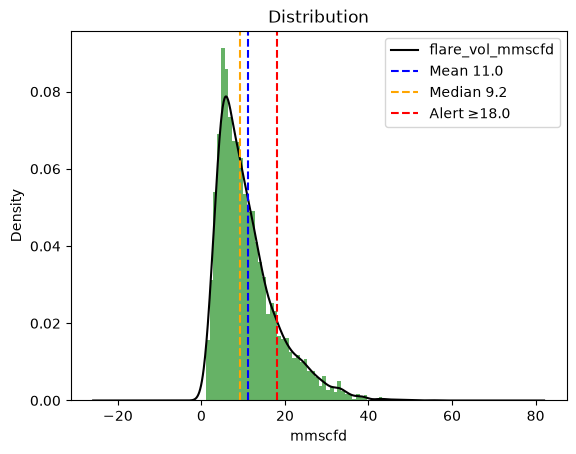

In [5]:


fig, ax = plt.subplots()
ax.hist(tgt, bins=60, density=True, color="green", alpha=0.6)
tgt.plot.kde(ax=ax, color="black")

ax.axvline(tgt.mean(),   color="blue", linestyle="--", label=f"Mean {tgt.mean():.1f}")
ax.axvline(tgt.median(), color="orange", linestyle="--", label=f"Median {tgt.median():.1f}")
ax.axvline(threshold,    color="red", linestyle="--", label=f"Alert ≥{threshold:.1f}")

ax.set_title("Distribution")
ax.set_xlabel("mmscfd")
ax.set_ylabel("Density")
ax.legend()

plt.show()




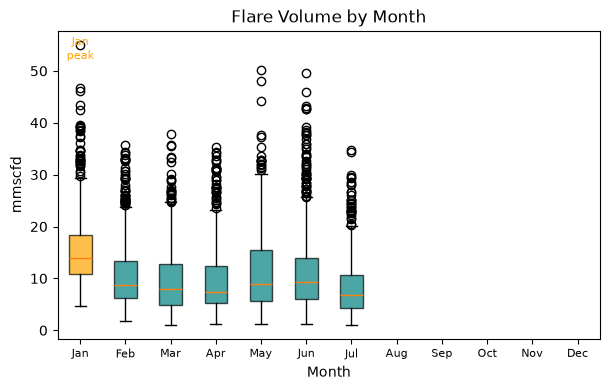

In [6]:
import matplotlib.pyplot as plt

# Prepare monthly data
monthly = [data.loc[data["month"] == m, "flare_vol_mmscfd"].dropna().values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(7,4))

# Boxplot
bp = ax.boxplot(monthly, patch_artist=True)

# Highlight January (first box)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("orange" if i == 0 else "teal")
    patch.set_alpha(0.7)

# Labels and title
ax.set_title("Flare Volume by Month")
ax.set_xlabel("Month")
ax.set_ylabel("mmscfd")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=8)

# Annotate January peak
ax.text(1, monthly[0].max()*0.95, "Jan\npeak", color="orange", fontsize=8, ha="center")

plt.show()


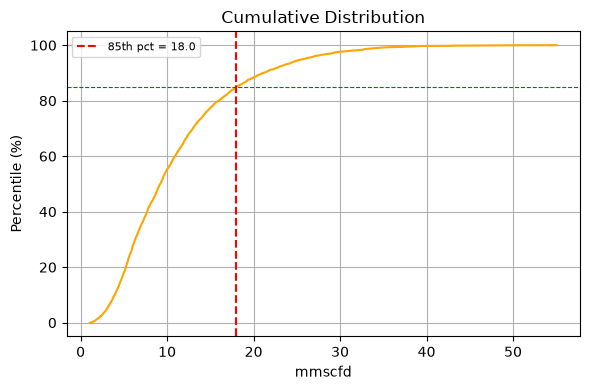

In [7]:
# Sort values and compute CDF
sorted_vals = np.sort(tgt)
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

fig, ax = plt.subplots(figsize=(6,4))

# Plot CDF
ax.plot(sorted_vals, cdf*100, color="orange", linewidth=1.5)

# Threshold line and 85th percentile marker
ax.axvline(threshold, color="red", linestyle="--", label=f"85th pct = {threshold:.1f}")
ax.axhline(85, color="green", linestyle="--", linewidth=0.8)

# Labels and title
ax.set_title("Cumulative Distribution")
ax.set_xlabel("mmscfd")
ax.set_ylabel("Percentile (%)")
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

Top correlations with target:
flare_roll_mean_6h    0.724
flare_lag_1h          0.561
compressor_trip_6h    0.504
planned_shutdown      0.481
flare_roll_std_24h    0.356
flare_lag_6h          0.303
flare_lag_24h         0.223
gor_scf_stb           0.089
gor_delta_6h          0.052
water_cut_pct         0.049
Name: flare_vol_mmscfd, dtype: float64


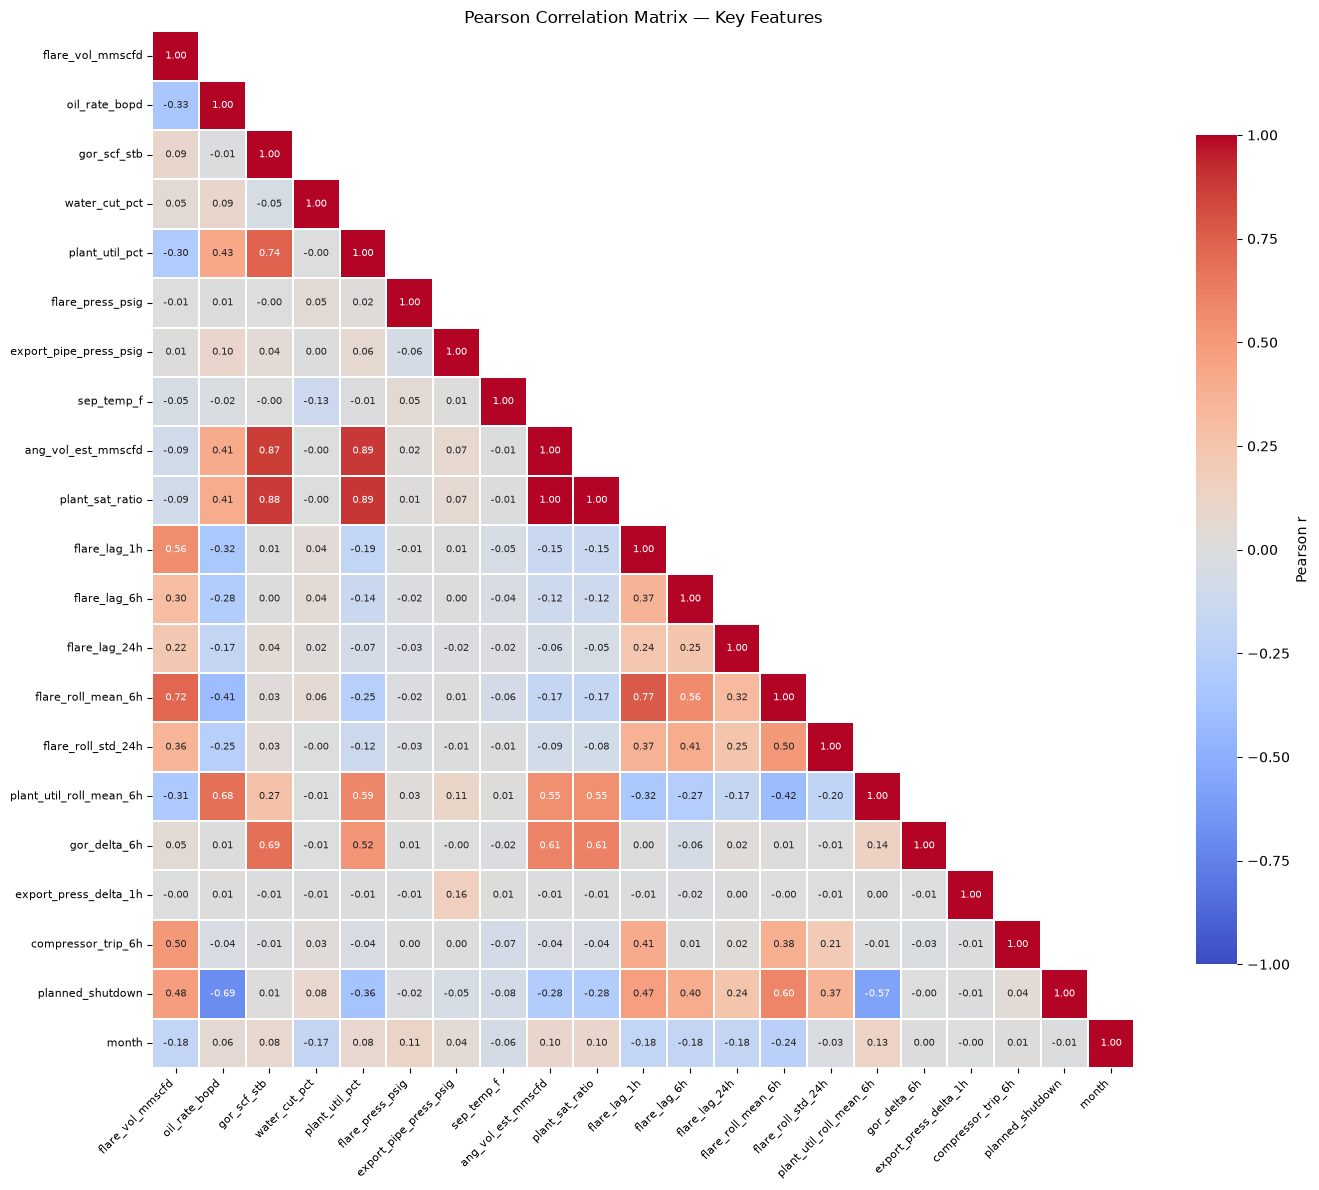

In [8]:
# Select columns
heatmap_cols = [
    "flare_vol_mmscfd",
    "oil_rate_bopd", "gor_scf_stb", "water_cut_pct",
    "plant_util_pct", "flare_press_psig", "export_pipe_press_psig",
    "sep_temp_f", "ang_vol_est_mmscfd", "plant_sat_ratio",
    "flare_lag_1h", "flare_lag_6h", "flare_lag_24h",
    "flare_roll_mean_6h", "flare_roll_std_24h",
    "plant_util_roll_mean_6h", "gor_delta_6h",
    "export_press_delta_1h", "compressor_trip_6h",
    "planned_shutdown", "month"
]

# Correlation matrix
corr_data = data[heatmap_cols].corr()

# Print top correlations with target
print("Top correlations with target:")
print(
    corr_data["flare_vol_mmscfd"]
    .drop("flare_vol_mmscfd")
    .sort_values(ascending=False)
    .head(10)
    .round(3)
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_data, dtype=bool), k=1)

sns.heatmap(
    corr_data, mask=mask, cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.3, ax=ax, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

ax.set_title("Pearson Correlation Matrix — Key Features")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

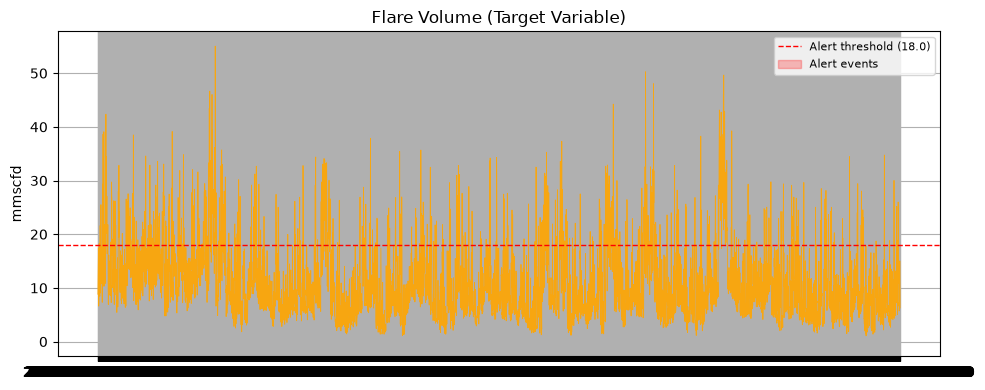

In [9]:
fig, ax = plt.subplots(figsize=(10,4))

# Flare volume line
ax.plot(data["timestamp"], data["flare_vol_mmscfd"], color="orange", linewidth=0.6, alpha=0.9)

# Threshold line
ax.axhline(threshold, color="red", linestyle="--", linewidth=1, label=f"Alert threshold ({threshold:.1f})")

# Shade alert periods
ax.fill_between(
    data["timestamp"], 0, data["flare_vol_mmscfd"],
    where=data["flare_alert"] == 1,
    color="red", alpha=0.25, label="Alert events"
)

# Labels and formatting
ax.set_ylabel("mmscfd")
ax.set_title("Flare Volume (Target Variable)")
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

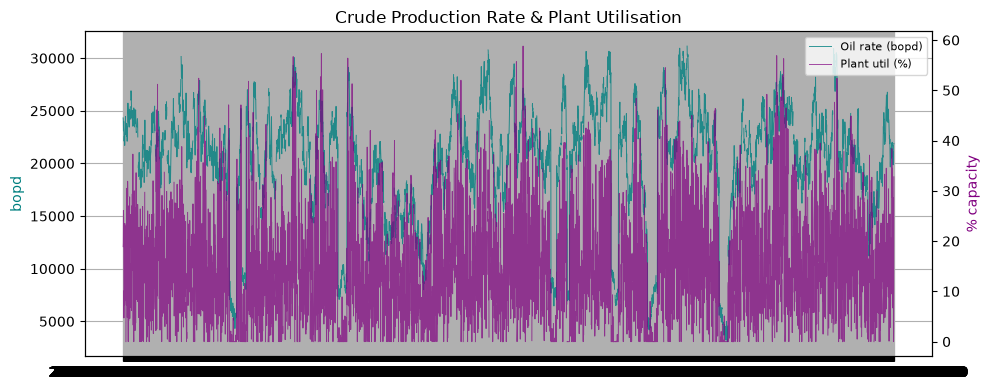

In [11]:
fig, ax = plt.subplots(figsize=(10,4))
ax2 = ax.twinx()

# Oil rate (left axis)
ax.plot(data["timestamp"], data["oil_rate_bopd"], color="teal", linewidth=0.7, alpha=0.8, label="Oil rate (bopd)")
ax.set_ylabel("bopd", color="teal")

# Plant utilization (right axis)
ax2.plot(data["timestamp"], data["plant_util_pct"], color="purple", linewidth=0.7, alpha=0.7, label="Plant util (%)")
ax2.set_ylabel("% capacity", color="purple")

# Title
ax.set_title("Crude Production Rate & Plant Utilisation")

# Combine legends
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper right")

ax.grid(True)
plt.tight_layout()
plt.show()


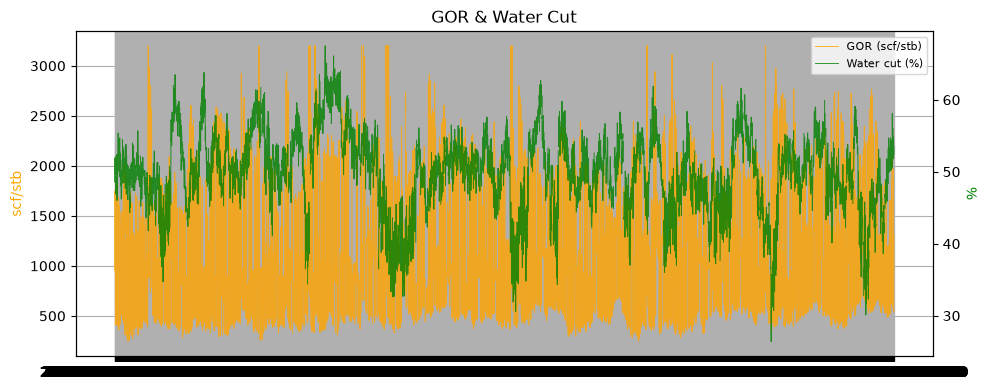

In [10]:
#
fig, ax = plt.subplots(figsize=(10,4))
ax2 = ax.twinx()

# GOR (left axis)
ax.plot(data["timestamp"], data["gor_scf_stb"], color="orange", linewidth=0.7, alpha=0.8, label="GOR (scf/stb)")
ax.set_ylabel("scf/stb", color="orange")

# Water cut (right axis)
ax2.plot(data["timestamp"], data["water_cut_pct"], color="green", linewidth=0.7, alpha=0.8, label="Water cut (%)")
ax2.set_ylabel("%", color="green")

# Title
ax.set_title("GOR & Water Cut")

# Combine legends
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper right")

ax.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# 1. Convert your date column to datetime format
data['timestamp'] = pd.to_datetime(data['timestamp'])

# 2. Set that column as the index
data = data.set_index('timestamp')

# 3. Now run the code again (it will work now)
is_january = data.index.month == 1
jan_y = tgt[is_january]
other_y = tgt[~is_january]


In [13]:
# Re-extract your target directly from the updated data object
tg = data['flare_vol_mmscfd']

# Now your original code works seamlessly without errors
trip_y = tg[data['compressor_trip_6h'] == 1]
no_trip_y = tg[data['compressor_trip_6h'] == 0]


In [14]:
print(f"{'='*55}")
print("         SECTION 9 — EDA SUMMARY FINDINGS")
print(f"{'='*55}")

corr_target = data[heatmap_cols].corr()["flare_vol_mmscfd"].drop("flare_vol_mmscfd").abs().sort_values(ascending=False)

print("\nTop 10 feature correlations with target:")
for feat, val in corr_target.head(10).items():
    bar = "█" * int(val * 30)
    print(f"  {feat:<35} {bar}  {val:.3f}")

print("\nKey findings:")
print(f"  1. Target skewness = {tgt.skew():.2f}; log transform may help SVR/LSTM")
print(f"  2. January mean flare is {(jan_y.mean()/other_y.mean()-1)*100:.0f}% above rest of year")
print(f"  3. Compressor trip raises mean flare by {(trip_y.mean()/no_trip_y.mean()-1)*100:.0f}%")
print(f"  4. flare_roll_mean_6h r={corr_target['flare_roll_mean_6h']:.2f} ")
print(f"  5. compressor_trip_6h r={corr_target['compressor_trip_6h']:.2f} ")
print(f"  6. Overall missing data = {data.isna().mean().mean()*100:.1f}%")
print(f"  7. Alert class balance: {data['flare_alert'].mean()*100:.1f}% ")


         SECTION 9 — EDA SUMMARY FINDINGS

Top 10 feature correlations with target:
  flare_roll_mean_6h                  █████████████████████  0.724
  flare_lag_1h                        ████████████████  0.561
  compressor_trip_6h                  ███████████████  0.504
  planned_shutdown                    ██████████████  0.481
  flare_roll_std_24h                  ██████████  0.356
  oil_rate_bopd                       █████████  0.332
  plant_util_roll_mean_6h             █████████  0.313
  flare_lag_6h                        █████████  0.303
  plant_util_pct                      ████████  0.295
  flare_lag_24h                       ██████  0.223

Key findings:
  1. Target skewness = 1.43; log transform may help SVR/LSTM
  2. January mean flare is 52% above rest of year
  3. Compressor trip raises mean flare by 95%
  4. flare_roll_mean_6h r=0.72 
  5. compressor_trip_6h r=0.50 
  6. Overall missing data = 3.5%
  7. Alert class balance: 15.0% 


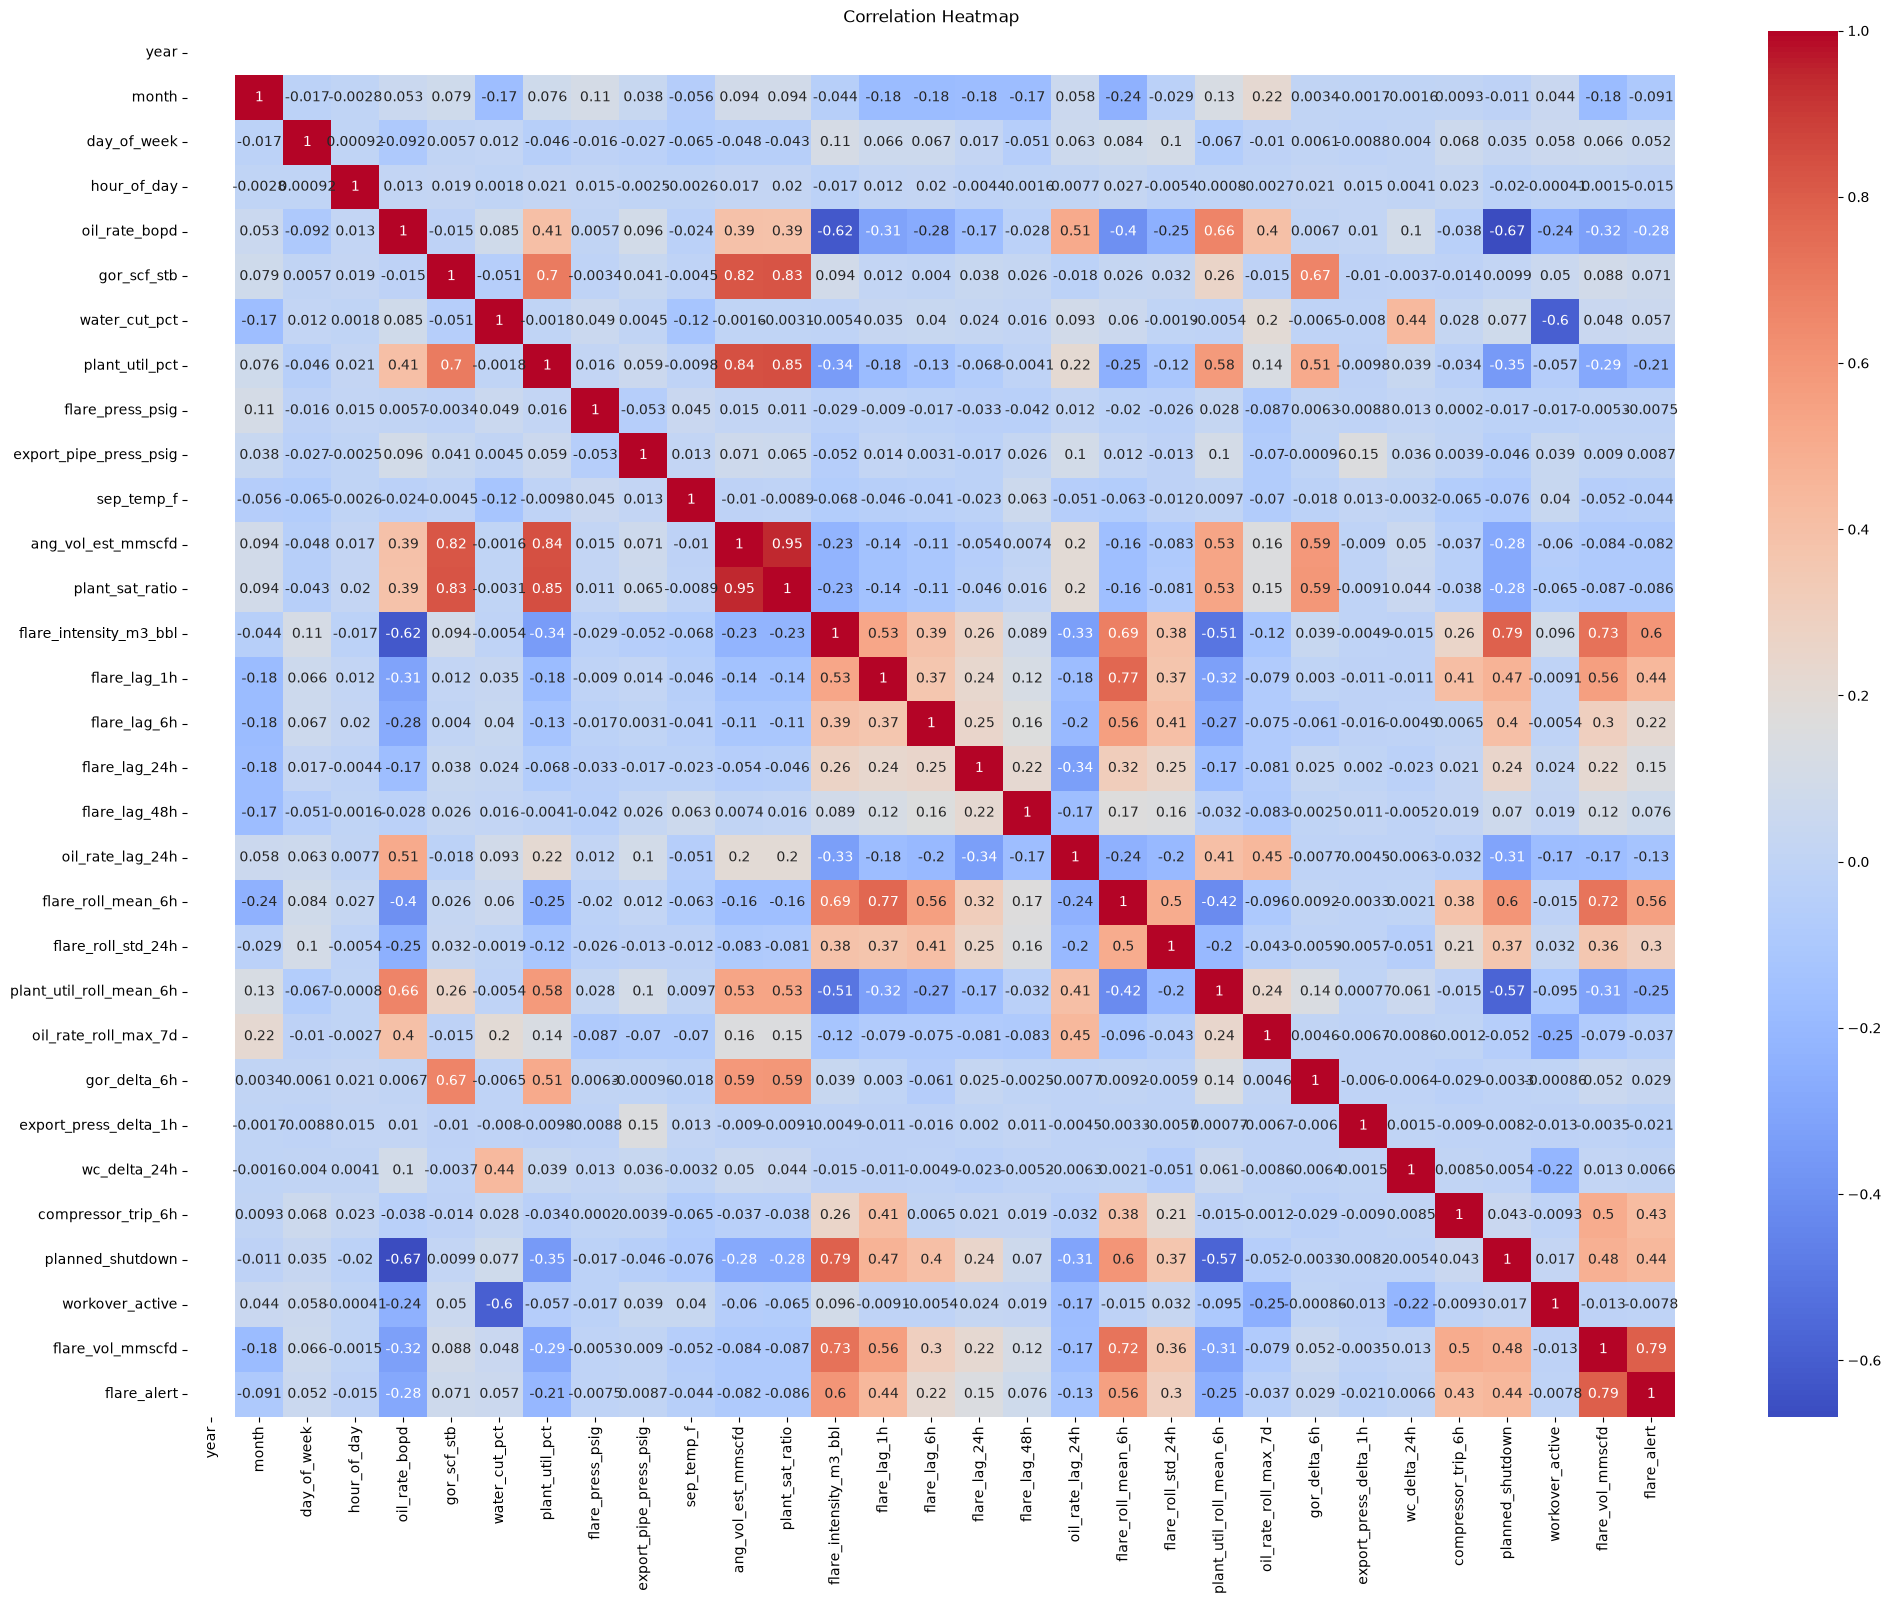

In [22]:
#Correlation heatmap
plt.figure(figsize=(24,18))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

### 2. Preprocessing

In [16]:
#Checking the dimensions of the dataset
print(f' The dimension of the data is: ', data.shape)

 The dimension of the data is:  (5000, 31)


In [17]:
#Checking the columns with missing data
miss = data.isna().mean() * 100
miss_nz = miss[miss > 0].sort_values(ascending=False)
print(miss_nz.round(2).to_string())
print(f"\nOverall missing: {miss.mean():.2f}%")
print(f"Columns with any missing: {(miss > 0).sum()}")

oil_rate_bopd              5.50
ang_vol_est_mmscfd         5.48
wc_delta_24h               5.38
flare_intensity_m3_bbl     5.34
flare_press_psig           5.16
flare_roll_std_24h         5.02
water_cut_pct              5.00
flare_lag_48h              4.96
gor_delta_6h               4.96
flare_roll_mean_6h         4.92
plant_util_roll_mean_6h    4.90
flare_lag_6h               4.90
export_pipe_press_psig     4.90
plant_sat_ratio            4.86
sep_temp_f                 4.86
flare_lag_1h               4.84
oil_rate_roll_max_7d       4.84
export_press_delta_1h      4.82
plant_util_pct             4.78
gor_scf_stb                4.66
oil_rate_lag_24h           4.26
flare_lag_24h              4.24

Overall missing: 3.50%
Columns with any missing: 22


In [58]:
missing_cols = ['oil_rate_bopd', 'gor_scf_stb', 'water_cut_pct', 'plant_util_pct',
       'flare_press_psig', 'export_pipe_press_psig', 'sep_temp_f',
       'ang_vol_est_mmscfd', 'plant_sat_ratio', 'flare_intensity_m3_bbl']
for col in missing_cols:
    data[col] = data[col].fillna(data[col].median())

In [59]:
data['flare_alert'].value_counts()

flare_alert
0    4250
1     750
Name: count, dtype: int64

In [60]:
#Count total rows for each label
data['flare_alert'].value_counts()
print("Class distribution:\n", (data['flare_alert'].value_counts(normalize=True) * 100).round(2))
if data['flare_alert'].value_counts().min() / data['flare_alert'].value_counts().max() < 0.1:
    print("Warning: Class imbalance detected!")
else:
    print("Class imbalance manageable. No special handling needed.")

Class distribution:
 flare_alert
0    85.0
1    15.0
Name: proportion, dtype: float64
Class imbalance manageable. No special handling needed.


In [63]:
features = ['flare_roll_mean_6h', 'flare_lag_1h', 'compressor_trip_6h',
             'planned_shutdown', 'flare_roll_std_24h', 'flare_lag_6h', 
             'flare_lag_24h', 'gor_scf_stb', 'gor_delta_6h', 'water_cut_pct', 'flare_intensity_m3_bbl']
x = data[features].values
y = data['flare_vol_mmscfd'].values

In [64]:
y.shape

(5000,)

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

In [ ]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)


In [67]:
#Checking the model's performance metrics
mae  = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
#Print them
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print(r2)

Mean Absolute Error (MAE): 1.5194590000000001
Mean Squared Error (MSE): 5.4552459518954
Root Mean Squared Error (RMSE): 2.3356467951930147
0.8931892215942104


In [68]:

threshold = np.percentile(y_pred, 85)
anomalies = y_pred > threshold
for i, value in enumerate(y_pred):
    if value > threshold:
        print(f"Alert: Prediction {value:.2f} at index {i} exceeds 85th percentile threshold {threshold:.2f}")


Alert: Prediction 32.36 at index 4 exceeds 85th percentile threshold 17.94
Alert: Prediction 26.37 at index 6 exceeds 85th percentile threshold 17.94
Alert: Prediction 18.82 at index 13 exceeds 85th percentile threshold 17.94
Alert: Prediction 21.78 at index 24 exceeds 85th percentile threshold 17.94
Alert: Prediction 21.49 at index 25 exceeds 85th percentile threshold 17.94
Alert: Prediction 18.04 at index 28 exceeds 85th percentile threshold 17.94
Alert: Prediction 18.19 at index 30 exceeds 85th percentile threshold 17.94
Alert: Prediction 37.23 at index 45 exceeds 85th percentile threshold 17.94
Alert: Prediction 20.36 at index 58 exceeds 85th percentile threshold 17.94
Alert: Prediction 21.28 at index 62 exceeds 85th percentile threshold 17.94
Alert: Prediction 27.75 at index 76 exceeds 85th percentile threshold 17.94
Alert: Prediction 20.45 at index 77 exceeds 85th percentile threshold 17.94
Alert: Prediction 22.35 at index 85 exceeds 85th percentile threshold 17.94
Alert: Predict

In [76]:
# Example new data
x_new = [[57.1, 30.5, 81.4, 90.2, 50, 76, 450, 78, 88, 61.32, 99]]  # replace with your feature vector

# Predict
y_new_pred = rf.predict(x_new)[0]

# Flag anomaly
is_anomaly = y_new_pred > threshold

if is_anomaly:
    print(f"ALERT: Prediction {y_new_pred:.2f} exceeds 85th percentile threshold {threshold:.2f}")
else:
    print(f"Prediction {y_new_pred:.2f} is normal")


Prediction 16.67 is normal
